# Florence Airbnb – Model Notebook

In this notebook we build and evaluate models to predict Airbnb listing prices in Florence using the engineered dataset `listings_features.csv`.

The notebook is structured as follows:

1. The outlier/price-filtering decision and the train/validation/test split are made **once**, at the top, and reused by every model below so that all models are compared on exactly the same data.
2. Gradient boosting models are compared on both the **raw price** and the **log‑transformed price** as a target.
3. Hyperparameter tuning is done with a single, systematic **Optuna** search for both XGBoost and CatBoost.
4. A **hybrid model** (k‑NN spatial signal + gradient boosting) combines the two families, a **robustness check** across multiple random splits quantifies how stable the results are, feature importance is computed with SHAP values, and the final model is exported.

We go through, in order: k‑NN baselines, CatBoost, XGBoost, hyperparameter tuning, Random Forest, the hybrid model, an overall comparison, a multi‑seed robustness check, SHAP feature importance, error analysis, and finally exporting the chosen model.

## Imports and Data Loading

All libraries used in this notebook are imported here: data handling and plotting, the preprocessing/model-selection tools from scikit‑learn, the two gradient boosting libraries (CatBoost, XGBoost), Optuna for hyperparameter search, and `joblib` for exporting the final model. The feature-engineered dataset produced by the cleaning notebook is loaded as the starting point for everything below.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

from catboost import CatBoostRegressor, Pool
from xgboost import XGBRegressor
import xgboost as xgb

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import joblib

data = pd.read_csv('data/listings_features.csv')
data.shape

(12093, 191)

## Plot Style

All plots in this notebook share one consistent color palette, defined once here and reused everywhere below.

In [2]:
from matplotlib.colors import LinearSegmentedColormap

COLOR_PRIMARY = "#D6749B"
COLOR_PRIMARY_DARK = "#B85580"
COLOR_SECONDARY = "#7E9B53"
COLOR_SECONDARY_LIGHT = "#E9F1DC"
COLOR_TEXT = "#4C3A41"
COLOR_BACKGROUND = "#FBF3EE"

COLOR_SURFACE = "#FCF6F8"
COLOR_GRID = "#EEDCE3"
COLOR_PRIMARY_SOFT = "#FBE6EE"
COLOR_ACCENT = "#5F7B3B"

plt.rcParams.update({
    "figure.facecolor": COLOR_SURFACE,
    "axes.facecolor": COLOR_SURFACE,
    "axes.edgecolor": COLOR_GRID,
    "axes.labelcolor": COLOR_TEXT,
    "axes.titleweight": "bold",
    "text.color": COLOR_TEXT,
    "xtick.color": COLOR_TEXT,
    "ytick.color": COLOR_TEXT,
    "grid.color": COLOR_GRID,
    "grid.alpha": 0.6,
    "legend.facecolor": COLOR_SURFACE,
    "legend.edgecolor": COLOR_GRID,
})

PLOT_PALETTE = [COLOR_PRIMARY, COLOR_SECONDARY, COLOR_PRIMARY_DARK, COLOR_ACCENT, COLOR_PRIMARY_SOFT, COLOR_SECONDARY_LIGHT]
sns.set_palette(PLOT_PALETTE)

# diverging rose -> warm light gray -> sage colormap, used for the residual map further down.
# A direct rose-to-sage blend with no neutral midpoint came out muddy, so a light
# warm gray sits in between instead of white or a direct blend.
RESIDUAL_CMAP = LinearSegmentedColormap.from_list(
    "residual_diverging",
    [COLOR_PRIMARY_DARK, "#DAD4CC", COLOR_ACCENT]
)

## Tracking Model Performance

An empty list `model_results` is initialized to collect the evaluation metrics (RMSE and MAE, on validation and test) of every model trained in this notebook, so they can all be compared side by side at the end.

In [3]:
model_results = []

## 1. Data Preparation

Before training any model, three decisions are made once and then reused everywhere below: how to treat extreme prices, which target scale to explore, and how to split the data. Doing this in one place means every model is trained and evaluated on exactly the same rows, which makes the final comparison fair.

### 1.1 Handling extreme prices

The price distribution is inspected first. A small number of listings have very high nightly prices, which can dominate an RMSE-based comparison if left in.

In [4]:
print("Min price:", data["price"].min())
print("Max price:", data["price"].max())
print("95th percentile:", data["price"].quantile(0.95))
print("99th percentile:", data["price"].quantile(0.99))

Min price: 10.0
Max price: 18547.0
95th percentile: 585.3999999999996
99th percentile: 2060.4399999999987


Two strategies were tried for handling these extreme values: **capping** extreme prices at the 99th percentile (keeping all rows) versus **removing** listings above the 99th percentile entirely. Removing performed clearly better (lower test RMSE for CatBoost), so that is the strategy used throughout the rest of this notebook. The capping variant is not shown here to avoid duplicating the whole modeling pipeline for an approach that already lost.

In [5]:
cap_value = data["price"].quantile(0.99)
data_model = data[data["price"] <= cap_value].copy()
print("Rows before filtering:", len(data))
print("Rows after filtering: ", len(data_model))

Rows before filtering: 12093
Rows after filtering:  11972


### 1.2 Merging review-based features

A second, review-derived feature table (`reviews_features.csv`) is joined onto the listings on `id`. It contributes review volume/recency (`rev_n_reviews`, `rev_per_month`, `rev_n_last_year`, `rev_days_since_last`, `rev_days_since_first`), review text length (`rev_len_chars_mean`, `rev_len_words_mean`), and review sentiment (`rev_sent_mean`, `rev_sent_std`, `rev_sent_min`, `rev_frac_negative`) signals that are not covered by the existing `review_scores_*` columns, which only capture guests' explicit star ratings.

Not every listing has reviews, so the join leaves some rows with missing values. A `reviews_features_missing` flag records which rows those are, and the missing values themselves are filled: 0 for counts and rates (no reviews means zero of everything), and the column median for the length/sentiment/recency statistics that are simply undefined without any reviews to compute them from.

In [6]:
reviews_features = pd.read_csv("data/reviews_features.csv")
data_model = data_model.merge(reviews_features, on="id", how="left")

data_model["reviews_features_missing"] = data_model["rev_n_reviews"].isna().astype(int)

review_zero_fill_cols = ["rev_n_reviews", "rev_per_month", "rev_n_last_year", "rev_frac_negative"]
review_median_fill_cols = [
    "rev_len_chars_mean", "rev_len_words_mean",
    "rev_days_since_last", "rev_days_since_first",
    "rev_sent_mean", "rev_sent_std", "rev_sent_min",
]

for c in review_zero_fill_cols:
    data_model[c] = data_model[c].fillna(0)
for c in review_median_fill_cols:
    data_model[c] = data_model[c].fillna(data_model[c].median())

print("Listings with no reviews:", data_model["reviews_features_missing"].sum(), "/", len(data_model))

Listings with no reviews: 1171 / 11972


### 1.3 Target scale: raw price vs. log price

For the k‑NN baselines, the price is heavily right‑skewed, so the log‑transformed price is used as the target. For the gradient boosting models later on, both the raw price and the log price are tried explicitly and compared, since it is not obvious upfront whether log‑scaling helps tree‑based models as much as it helps k‑NN.

In [7]:
data_model["log_price"] = np.log1p(data_model["price"])

### 1.4 A single train / validation / test split

Instead of re-splitting the data separately (and slightly differently) inside every model section, one 70/15/15 split is created here and reused by every model below.

In [8]:
train_df, temp_df = train_test_split(data_model, test_size=0.3, random_state=42)
valid_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print("Train:", len(train_df), " Valid:", len(valid_df), " Test:", len(test_df))

Train: 8380  Valid: 1796  Test: 1796


### 1.5 Feature sets

Two feature sets are used throughout the notebook:

- `knn_*`: a smaller set (location, capacity, review counts and review-text features, text-length and keyword features, amenity count, neighbourhood/property/room type) used for the k‑NN models, matching the original k‑NN experiments.
- `all_features`: the larger set additionally used for the gradient boosting / Random Forest models, which also includes the individual review-score columns and the location-derived distance/cluster/density features engineered in the cleaning notebook.

Every model below except the very first (the location-only k‑NN baseline, which deliberately uses only latitude/longitude) is trained on one of these two sets, so the newly added review-based features from `reviews_features.csv` flow into every one of them automatically.

In [9]:
num_features_knn = [
    "latitude", "longitude",
    "accommodates", "bathrooms", "bedrooms", "beds",
    "minimum_nights", "maximum_nights",
    "number_of_reviews",
    "description_len_chars", "description_len_words",
    "nb_overview_len_chars", "nb_overview_len_words",
    "amenities_count",
    "rev_n_reviews", "rev_len_chars_mean", "rev_len_words_mean",
    "rev_days_since_last", "rev_days_since_first", "rev_per_month",
    "rev_n_last_year", "rev_sent_mean", "rev_sent_std", "rev_sent_min",
    "rev_frac_negative",
]

bool_features_knn = [
    "review_scores_missing", "bathrooms_text_missing", "bath_shared",
    "bath_private_flag", "bath_half", "description_missing",
    "desc_kw_luxury", "desc_kw_modern", "desc_kw_spacious", "desc_kw_cozy",
    "desc_kw_quiet", "desc_kw_charming", "desc_kw_unforgattable",
    "desc_kw_relaxing", "desc_kw_everything you need", "desc_kw_cute",
    "desc_kw_comfortable", "neighborhood_overview_missing",
    "nb_cat_transport", "nb_cat_food_places", "nb_cat_shops",
    "nb_cat_sights", "nb_cat_nightlife", "nb_cat_greenery",
    "nb_cat_quiet_residential",
    "reviews_features_missing",
]

cat_features = ["neighbourhood_cleansed", "property_type", "room_type"]

knn_feature_cols = num_features_knn + bool_features_knn + cat_features

num_features_full = num_features_knn + [
    "review_scores_rating", "review_scores_accuracy",
    "review_scores_cleanliness", "review_scores_checkin",
    "review_scores_communication", "review_scores_location",
    "review_scores_value",
    "dist_duomo_km", "dist_campanile_km", "dist_baptistery_km",
    "dist_signoria_km", "dist_vecchio_palace_km", "dist_center_km",
    "angle_from_center", "cluster_price_median", "cluster_price_mean",
    "cluster_reviews_mean", "cluster_rating_mean", "local_density",
]
bool_features_full = bool_features_knn + ["south_of_arno"]

all_features = num_features_full + bool_features_full + cat_features
len(knn_feature_cols), len(all_features)

(54, 74)

## 2. Baseline k‑NN (location only)

As a simple baseline, a k‑Nearest Neighbours regressor uses only latitude and longitude to predict the log‑price. This tells us how much of the price variation can be explained by **location alone**, before adding any other information.

In [10]:
knn_location_features = ["latitude", "longitude"]

X_train = train_df[knn_location_features]; y_train = train_df["log_price"]
X_valid = valid_df[knn_location_features]; y_valid = valid_df["log_price"]
X_test  = test_df[knn_location_features];  y_test  = test_df["log_price"]

loc_scaler = StandardScaler().fit(X_train)
X_train_s = loc_scaler.transform(X_train)
X_valid_s = loc_scaler.transform(X_valid)
X_test_s  = loc_scaler.transform(X_test)

### 2.1 Choosing the number of neighbours k

Candidate values of k from 1 to 60 are evaluated: for each k, a k‑NN regressor is trained on the (scaled) training coordinates and its validation RMSE, on the log‑price scale, is recorded. The best k found here is stored in `best_k_loc` and reused directly below, instead of reading the plot and re-typing the number by hand.

In [11]:
k_values = range(1, 61)
rmse_scores = []

for k in k_values:
    knn_reg = KNeighborsRegressor(n_neighbors=k, weights="distance")
    knn_reg.fit(X_train_s, y_train)
    pred = knn_reg.predict(X_valid_s)
    rmse_scores.append(np.sqrt(mean_squared_error(y_valid, pred)))

def select_simplest_k(k_values, rmse_scores, tol=0.01):
    """Smallest k whose RMSE is within `tol` (relative) of the best RMSE found.

    Taking the raw minimum (argmin) over k keeps improving only marginally all
    the way out to the edge of the tested range here, so it just picks the
    boundary of the search space rather than a meaningful "elbow". This rule
    instead picks the simplest (smallest) k that is essentially as good as the
    best one found.
    """
    k_values = list(k_values)
    rmse_scores = np.asarray(rmse_scores)
    best_rmse = rmse_scores.min()
    threshold = best_rmse * (1 + tol)
    candidates = [k for k, r in zip(k_values, rmse_scores) if r <= threshold]
    return min(candidates)

best_k_loc = select_simplest_k(k_values, rmse_scores)
print("Best k (location only):", best_k_loc)

Best k (location only): 24


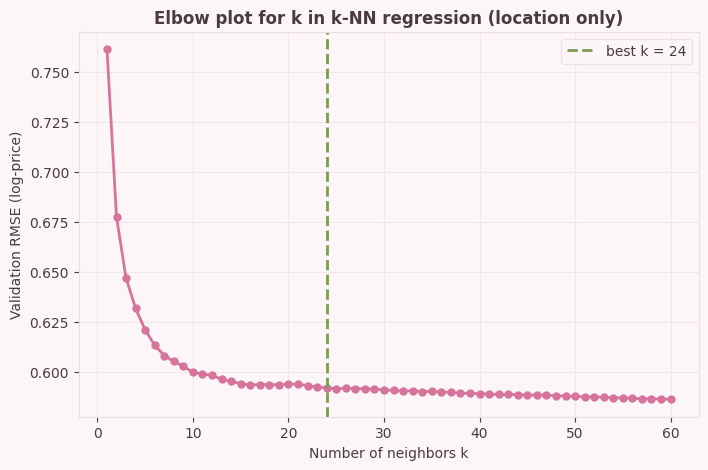

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(list(k_values), rmse_scores, marker="o", color=COLOR_PRIMARY, linewidth=2, markersize=5)
plt.axvline(best_k_loc, color=COLOR_SECONDARY, linestyle="--", linewidth=2, label=f"best k = {best_k_loc}")
plt.xlabel("Number of neighbors k")
plt.ylabel("Validation RMSE (log-price)")
plt.title("Elbow plot for k in k-NN regression (location only)")
plt.legend()
plt.grid(True)
plt.show()

A few different ways of picking `best_k_loc` from this curve were tried. Taking the raw minimum (`argmin`) keeps improving only marginally all the way out to the edge of the tested range, so it just ends up picking the boundary of the search space (k=60) rather than a meaningful elbow. That k offers no real benefit over a much smaller, simpler value. Instead, `best_k_loc` is chosen as the **smallest k within 1% of the best validation RMSE found** (`select_simplest_k`), which favors a simpler, less-smoothed model whenever the extra neighbours barely help.

### 2.2 Final model and evaluation

The k‑NN model is (re)trained with `best_k_loc` neighbours and evaluated on validation and test, after converting predictions back from log‑price to euros.

In [13]:
knn_location_model = KNeighborsRegressor(n_neighbors=best_k_loc, weights="distance")
knn_location_model.fit(X_train_s, y_train)

pred_valid = np.expm1(knn_location_model.predict(X_valid_s))
pred_test  = np.expm1(knn_location_model.predict(X_test_s))
true_valid = np.expm1(y_valid)
true_test  = np.expm1(y_test)

rmse_valid = np.sqrt(mean_squared_error(true_valid, pred_valid))
rmse_test  = np.sqrt(mean_squared_error(true_test, pred_test))
mae_valid  = mean_absolute_error(true_valid, pred_valid)
mae_test   = mean_absolute_error(true_test, pred_test)

print("Validation RMSE:", rmse_valid, " MAE:", mae_valid)
print("Test RMSE:      ", rmse_test,  " MAE:", mae_test)

model_results.append({
    "name": "knn_location",
    "description": "knn, location only, log target, filtered prices",
    "rmse_valid": rmse_valid, "rmse_test": rmse_test,
    "mae_valid": mae_valid, "mae_test": mae_test,
})

Validation RMSE: 189.81213411978044  MAE: 94.76023614376854
Test RMSE:       169.50288915158737  MAE: 87.65097553305313


## 3. Baseline k‑NN (with engineered features)

This second k‑NN baseline extends the location-only model with capacity, review, text-derived, and amenity features engineered in the cleaning notebook. Numeric, boolean, and categorical features are handled separately through a preprocessing pipeline (scaling, pass‑through, one‑hot encoding).

In [14]:
preprocess_knn = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_features_knn),
    ("bool", "passthrough", bool_features_knn),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
])

X_train = train_df[knn_feature_cols]; y_train = train_df["log_price"]
X_valid = valid_df[knn_feature_cols]; y_valid = valid_df["log_price"]
X_test  = test_df[knn_feature_cols];  y_test  = test_df["log_price"]

X_train_p = preprocess_knn.fit_transform(X_train)
X_valid_p = preprocess_knn.transform(X_valid)
X_test_p  = preprocess_knn.transform(X_test)

The same k search as above is repeated on the processed (scaled/encoded) feature matrix.

In [15]:
rmse_scores = []
for k in k_values:
    knn_reg = KNeighborsRegressor(n_neighbors=k, weights="distance")
    knn_reg.fit(X_train_p, y_train)
    pred = knn_reg.predict(X_valid_p)
    rmse_scores.append(np.sqrt(mean_squared_error(y_valid, pred)))

# same tolerance-based rule as the location-only k-NN above, reusing select_simplest_k
best_k_all = select_simplest_k(k_values, rmse_scores)
print("Best k (engineered features):", best_k_all)

Best k (engineered features): 8


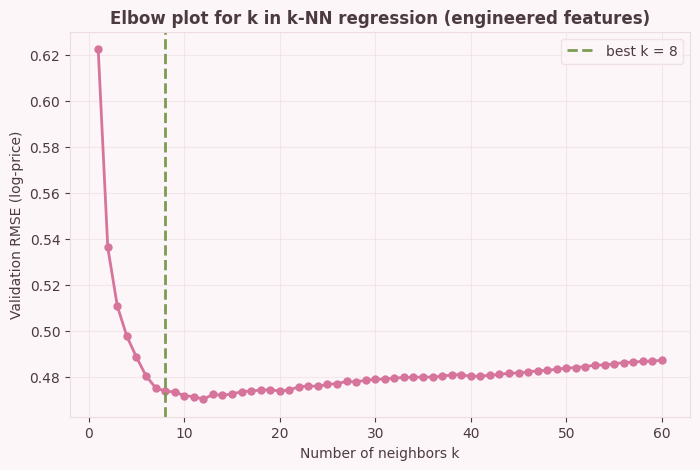

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(list(k_values), rmse_scores, marker="o", color=COLOR_PRIMARY, linewidth=2, markersize=5)
plt.axvline(best_k_all, color=COLOR_SECONDARY, linestyle="--", linewidth=2, label=f"best k = {best_k_all}")
plt.xlabel("Number of neighbors k")
plt.ylabel("Validation RMSE (log-price)")
plt.title("Elbow plot for k in k-NN regression (engineered features)")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
knn_all_model = KNeighborsRegressor(n_neighbors=best_k_all, weights="distance")
knn_all_model.fit(X_train_p, y_train)

pred_valid = np.expm1(knn_all_model.predict(X_valid_p))
pred_test  = np.expm1(knn_all_model.predict(X_test_p))
true_valid = np.expm1(y_valid)
true_test  = np.expm1(y_test)

rmse_valid = np.sqrt(mean_squared_error(true_valid, pred_valid))
rmse_test  = np.sqrt(mean_squared_error(true_test, pred_test))
mae_valid  = mean_absolute_error(true_valid, pred_valid)
mae_test   = mean_absolute_error(true_test, pred_test)

print("Validation RMSE:", rmse_valid, " MAE:", mae_valid)
print("Test RMSE:      ", rmse_test,  " MAE:", mae_test)

model_results.append({
    "name": "knn_all",
    "description": "knn, engineered features, log target, filtered prices",
    "rmse_valid": rmse_valid, "rmse_test": rmse_test,
    "mae_valid": mae_valid, "mae_test": mae_test,
})

Validation RMSE: 155.53627445328993  MAE: 76.36394153993729
Test RMSE:       146.07328537159592  MAE: 71.28359340459859


Adding the engineered features noticeably improves k‑NN over the location-only baseline. There is no separate "filtered" variant shown here. The 99th‑percentile filtering already happened once for the whole notebook in section 1, so this model is already trained and evaluated on the filtered data.

## 4. Gradient Boosting: CatBoost

Gradient boosting models can capture non‑linear feature interactions much better than k‑NN and can natively handle categorical variables. CatBoost is tried first. Its `Pool` data structure needs to know the positions of the categorical columns within the feature matrix.

In [18]:
cat_feature_indices = [all_features.index(c) for c in cat_features]

train_pool_raw = Pool(train_df[all_features], train_df["price"], cat_features=cat_feature_indices)
valid_pool_raw = Pool(valid_df[all_features], valid_df["price"], cat_features=cat_feature_indices)
test_pool_raw  = Pool(test_df[all_features],  test_df["price"],  cat_features=cat_feature_indices)

train_pool_log = Pool(train_df[all_features], train_df["log_price"], cat_features=cat_feature_indices)
valid_pool_log = Pool(valid_df[all_features], valid_df["log_price"], cat_features=cat_feature_indices)
test_pool_log  = Pool(test_df[all_features],  test_df["log_price"],  cat_features=cat_feature_indices)

cb_params = dict(loss_function="RMSE", eval_metric="RMSE", depth=6, learning_rate=0.1,
                  n_estimators=1000, random_seed=42, verbose=False,
                  early_stopping_rounds=50)

### 4.1 Raw price target

In [19]:
catboost_raw = CatBoostRegressor(**cb_params)
catboost_raw.fit(train_pool_raw, eval_set=valid_pool_raw, use_best_model=True)

pred_valid = catboost_raw.predict(valid_pool_raw)
pred_test  = catboost_raw.predict(test_pool_raw)

rmse_valid = np.sqrt(mean_squared_error(valid_df["price"], pred_valid))
rmse_test  = np.sqrt(mean_squared_error(test_df["price"], pred_test))
mae_valid  = mean_absolute_error(valid_df["price"], pred_valid)
mae_test   = mean_absolute_error(test_df["price"], pred_test)

print("Validation RMSE:", rmse_valid, " MAE:", mae_valid)
print("Test RMSE:      ", rmse_test,  " MAE:", mae_test)

model_results.append({
    "name": "catboost_raw",
    "description": "catboost, all features, raw price, filtered",
    "rmse_valid": rmse_valid, "rmse_test": rmse_test,
    "mae_valid": mae_valid, "mae_test": mae_test,
})

Validation RMSE: 144.31158974280467  MAE: 71.88939917009868
Test RMSE:       133.6580097786609  MAE: 68.32619633269972


### 4.2 Log price target

The same fixed hyperparameters are used, but the model now predicts log‑price; predictions are converted back to euros before computing metrics, so the numbers are directly comparable to the raw-price model above.

In [20]:
catboost_log = CatBoostRegressor(**cb_params)
catboost_log.fit(train_pool_log, eval_set=valid_pool_log, use_best_model=True)

pred_valid = np.expm1(catboost_log.predict(valid_pool_log))
pred_test  = np.expm1(catboost_log.predict(test_pool_log))
true_valid = np.expm1(valid_df["log_price"])
true_test  = np.expm1(test_df["log_price"])

rmse_valid = np.sqrt(mean_squared_error(true_valid, pred_valid))
rmse_test  = np.sqrt(mean_squared_error(true_test, pred_test))
mae_valid  = mean_absolute_error(true_valid, pred_valid)
mae_test   = mean_absolute_error(true_test, pred_test)

print("Validation RMSE:", rmse_valid, " MAE:", mae_valid)
print("Test RMSE:      ", rmse_test,  " MAE:", mae_test)

model_results.append({
    "name": "catboost_log",
    "description": "catboost, all features, log price, filtered",
    "rmse_valid": rmse_valid, "rmse_test": rmse_test,
    "mae_valid": mae_valid, "mae_test": mae_test,
})

Validation RMSE: 145.81189144906483  MAE: 64.25024089071336
Test RMSE:       134.81940413952373  MAE: 60.246099774000186


Raw price and log price give almost the same test RMSE for CatBoost, but the log‑price model has a clearly lower MAE (typical error in euros). Since RMSE weighs a few very expensive listings much more heavily, while MAE reflects the *typical* prediction error, this suggests log‑price gives more consistent everyday predictions even though it doesn't reduce RMSE much. The same raw‑vs‑log comparison is repeated for XGBoost below to see if the pattern holds.

### 4.3 Feature importance

CatBoost's built‑in feature importance is inspected to see which variables contribute most to the (log‑price) model's predictions.

In [21]:
importances = catboost_log.get_feature_importance(train_pool_log)
for name, imp in sorted(zip(all_features, importances), key=lambda x: -x[1])[:15]:
    print(f"{name}: {imp:.3f}")

bathrooms: 9.236
minimum_nights: 5.464
accommodates: 4.712
bedrooms: 4.167
property_type: 4.025
rev_days_since_last: 3.913
amenities_count: 3.769
rev_sent_mean: 3.555
cluster_reviews_mean: 2.597
dist_campanile_km: 2.552
rev_days_since_first: 2.382
maximum_nights: 2.357
dist_vecchio_palace_km: 2.305
dist_duomo_km: 2.254
local_density: 2.122


## 5. Gradient Boosting: XGBoost

XGBoost is tried as an alternative gradient boosting implementation. Unlike CatBoost, it needs categorical columns to be explicitly typed as `category` (its native categorical support) rather than passed as plain indices.

In [22]:
X_train = train_df[all_features].copy()
X_valid = valid_df[all_features].copy()
X_test  = test_df[all_features].copy()

# Casting each split to "category" independently can give each split a different
# set of categories, which then breaks prediction later with "category not in
# training set" errors. A single shared dtype, derived from the full
# data_model, is used for train/valid/test instead so the category sets always match.
for c in cat_features:
    cat_dtype = pd.CategoricalDtype(categories=data_model[c].astype("category").cat.categories)
    X_train[c] = X_train[c].astype(cat_dtype)
    X_valid[c] = X_valid[c].astype(cat_dtype)
    X_test[c]  = X_test[c].astype(cat_dtype)

xgb_params = dict(n_estimators=500, learning_rate=0.05, max_depth=8, subsample=0.8,
                   colsample_bytree=0.8, objective="reg:squarederror",
                   enable_categorical=True, random_state=42)

### 5.1 Raw price target

In [23]:
xgboost_raw = XGBRegressor(**xgb_params)
xgboost_raw.fit(X_train, train_df["price"])

pred_valid = xgboost_raw.predict(X_valid)
pred_test  = xgboost_raw.predict(X_test)

rmse_valid = np.sqrt(mean_squared_error(valid_df["price"], pred_valid))
rmse_test  = np.sqrt(mean_squared_error(test_df["price"], pred_test))
mae_valid  = mean_absolute_error(valid_df["price"], pred_valid)
mae_test   = mean_absolute_error(test_df["price"], pred_test)

print("Validation RMSE:", rmse_valid, " MAE:", mae_valid)
print("Test RMSE:      ", rmse_test,  " MAE:", mae_test)

model_results.append({
    "name": "xgboost_raw",
    "description": "xgboost, all features, raw price, filtered",
    "rmse_valid": rmse_valid, "rmse_test": rmse_test,
    "mae_valid": mae_valid, "mae_test": mae_test,
})

Validation RMSE: 145.46795748825036  MAE: 73.73995589466563
Test RMSE:       133.3174072307927  MAE: 69.53084995220924


### 5.2 Log price target

In [24]:
xgboost_log = XGBRegressor(**xgb_params)
xgboost_log.fit(X_train, train_df["log_price"])

pred_valid = np.expm1(xgboost_log.predict(X_valid))
pred_test  = np.expm1(xgboost_log.predict(X_test))
true_valid = np.expm1(valid_df["log_price"])
true_test  = np.expm1(test_df["log_price"])

rmse_valid = np.sqrt(mean_squared_error(true_valid, pred_valid))
rmse_test  = np.sqrt(mean_squared_error(true_test, pred_test))
mae_valid  = mean_absolute_error(true_valid, pred_valid)
mae_test   = mean_absolute_error(true_test, pred_test)

print("Validation RMSE:", rmse_valid, " MAE:", mae_valid)
print("Test RMSE:      ", rmse_test,  " MAE:", mae_test)

model_results.append({
    "name": "xgboost_log",
    "description": "xgboost, all features, log price, filtered",
    "rmse_valid": rmse_valid, "rmse_test": rmse_test,
    "mae_valid": mae_valid, "mae_test": mae_test,
})

Validation RMSE: 144.08029722209517  MAE: 63.29241300850509
Test RMSE:       133.68743359817782  MAE: 59.248315959836965


The same pattern as CatBoost shows up: the raw‑price XGBoost model actually has the single best test RMSE of all models trained so far, but the log‑price version has a substantially better MAE. Since the rest of this notebook (hyperparameter tuning, the hybrid model) is meant to build on **one** consistent target, log‑price is used from here on, mainly because of the more consistent, typical-case error (MAE) and because it matches the target scale already used for k‑NN. This trade-off is revisited explicitly in the model comparison section further down, since "log wins on MAE, raw wins on RMSE" is a real and useful finding, not just noise.

## 6. Hyperparameter Tuning (Optuna)

Manual grid search, grid search combined with cross-validation, and `RandomizedSearchCV` were all tried for tuning gradient boosting hyperparameters, but produced no clear winner and a lot of duplicated code between them. A single, systematic **Optuna** search is used instead first for XGBoost, then for CatBoost.

Each trial is scored by **4-fold cross-validation RMSE on the training set** (log-price), rather than a single train/valid split. Optimizing directly against one fixed validation split risks the search quietly overfitting to that particular split: with a single-split objective, increasing the trial budget stopped improving test-set performance (and even slightly hurt it) once the search had enough trials to start exploiting quirks of that one split, rather than finding genuinely better settings. Cross-validating each trial's score guards against this. `valid_df` and `test_df` stay completely untouched by the search itself and are only used afterward, once, to evaluate the final refit model.

### 6.1 XGBoost

In [25]:
def xgb_objective(trial):
    params = dict(
        max_depth=trial.suggest_int("max_depth", 4, 9),
        learning_rate=trial.suggest_float("learning_rate", 0.02, 0.15, log=True),
        n_estimators=trial.suggest_int("n_estimators", 200, 700),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 6),
        subsample=trial.suggest_float("subsample", 0.7, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.7, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 0.0, 2.0),
        reg_alpha=trial.suggest_float("reg_alpha", 0.0, 2.0),
    )
    kf = KFold(n_splits=4, shuffle=True, random_state=42)
    fold_rmses = []
    for tr_idx, va_idx in kf.split(X_train):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_va = train_df["log_price"].iloc[tr_idx], train_df["log_price"].iloc[va_idx]
        model = XGBRegressor(objective="reg:squarederror", enable_categorical=True,
                              random_state=42, n_jobs=-1, **params)
        model.fit(X_tr, y_tr)
        pred = model.predict(X_va)
        fold_rmses.append(np.sqrt(mean_squared_error(y_va, pred)))
    return float(np.mean(fold_rmses))

study = optuna.create_study(direction="minimize", study_name="xgb_log_price",
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(xgb_objective, n_trials=80)

print("Best CV RMSE (log-price):", study.best_value)
print("Best params:", study.best_params)

Best CV RMSE (log-price): 0.4076326624726791
Best params: {'max_depth': 7, 'learning_rate': 0.0256301629131768, 'n_estimators': 676, 'min_child_weight': 5, 'subsample': 0.7586356020410775, 'colsample_bytree': 0.789249168588227, 'reg_lambda': 0.328523164402301, 'reg_alpha': 0.08240521375702403}


The tuned hyperparameters are used to train the final XGBoost model on log‑price and evaluate it on validation/test, exactly like the untuned models above.

In [26]:
xgboost_tuned = XGBRegressor(objective="reg:squarederror", enable_categorical=True,
                              random_state=42, **study.best_params)
xgboost_tuned.fit(X_train, train_df["log_price"])

pred_valid = np.expm1(xgboost_tuned.predict(X_valid))
pred_test  = np.expm1(xgboost_tuned.predict(X_test))
true_valid = np.expm1(valid_df["log_price"])
true_test  = np.expm1(test_df["log_price"])

rmse_valid = np.sqrt(mean_squared_error(true_valid, pred_valid))
rmse_test  = np.sqrt(mean_squared_error(true_test, pred_test))
mae_valid  = mean_absolute_error(true_valid, pred_valid)
mae_test   = mean_absolute_error(true_test, pred_test)

print("Validation RMSE:", rmse_valid, " MAE:", mae_valid)
print("Test RMSE:      ", rmse_test,  " MAE:", mae_test)

model_results.append({
    "name": "xgboost_tuned",
    "description": "xgboost, all features, log price, optuna-tuned (12 trials)",
    "rmse_valid": rmse_valid, "rmse_test": rmse_test,
    "mae_valid": mae_valid, "mae_test": mae_test,
})

Validation RMSE: 143.7699683651726  MAE: 63.286797875019914
Test RMSE:       133.36101432403223  MAE: 59.28831643994508


Even with the more robust cross-validated objective, the tuned model stays close to the untuned log‑price XGBoost above rather than clearly beating it. With this trial budget, the search mostly confirms the untuned defaults were already reasonable. It is kept in the comparison anyway, both for transparency and because `study.best_params` is reused directly in the hybrid model below, so this search still matters even without a dramatic RMSE improvement.

### 6.2 CatBoost

The same kind of Optuna search is repeated for CatBoost, over its own hyperparameters (tree depth, learning rate, number of trees, L2 regularization) scored the same way, via 4-fold cross-validation RMSE on log‑price rather than a single validation split.

In [28]:
def catboost_objective(trial):
    params = dict(
        depth=trial.suggest_int("depth", 4, 9),
        learning_rate=trial.suggest_float("learning_rate", 0.02, 0.15, log=True),
        n_estimators=trial.suggest_int("n_estimators", 200, 600),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 8.0),
    )
    kf = KFold(n_splits=4, shuffle=True, random_state=42)
    fold_rmses = []
    for tr_idx, va_idx in kf.split(train_df):
        tr_fold = train_df.iloc[tr_idx]
        va_fold = train_df.iloc[va_idx]
        tr_pool = Pool(tr_fold[all_features], tr_fold["log_price"], cat_features=cat_feature_indices)
        va_pool = Pool(va_fold[all_features], va_fold["log_price"], cat_features=cat_feature_indices)
        model = CatBoostRegressor(loss_function="RMSE", eval_metric="RMSE", random_seed=42,
                                   verbose=False, early_stopping_rounds=30, **params)
        model.fit(tr_pool, eval_set=va_pool, use_best_model=True)
        pred = model.predict(va_pool)
        fold_rmses.append(np.sqrt(mean_squared_error(va_fold["log_price"], pred)))
    return float(np.mean(fold_rmses))

catboost_study = optuna.create_study(direction="minimize", study_name="catboost_log_price",
                                      sampler=optuna.samplers.TPESampler(seed=42))
catboost_study.optimize(catboost_objective, n_trials=40)

print("Best CV RMSE (log-price):", catboost_study.best_value)
print("Best params:", catboost_study.best_params)

Best CV RMSE (log-price): 0.4091446046332203
Best params: {'depth': 8, 'learning_rate': 0.07546062522424564, 'n_estimators': 486, 'l2_leaf_reg': 1.0633691454631728}


In [29]:
catboost_tuned = CatBoostRegressor(loss_function="RMSE", eval_metric="RMSE", random_seed=42,
                                    verbose=False, early_stopping_rounds=30, **catboost_study.best_params)
catboost_tuned.fit(train_pool_log, eval_set=valid_pool_log, use_best_model=True)

pred_valid = np.expm1(catboost_tuned.predict(valid_pool_log))
pred_test  = np.expm1(catboost_tuned.predict(test_pool_log))
true_valid = np.expm1(valid_df["log_price"])
true_test  = np.expm1(test_df["log_price"])

rmse_valid = np.sqrt(mean_squared_error(true_valid, pred_valid))
rmse_test  = np.sqrt(mean_squared_error(true_test, pred_test))
mae_valid  = mean_absolute_error(true_valid, pred_valid)
mae_test   = mean_absolute_error(true_test, pred_test)

print("Validation RMSE:", rmse_valid, " MAE:", mae_valid)
print("Test RMSE:      ", rmse_test,  " MAE:", mae_test)

model_results.append({
    "name": "catboost_tuned",
    "description": "catboost, all features, log price, optuna-tuned (8 trials)",
    "rmse_valid": rmse_valid, "rmse_test": rmse_test,
    "mae_valid": mae_valid, "mae_test": mae_test,
})

Validation RMSE: 148.6028355163643  MAE: 64.99411471434958
Test RMSE:       137.3444873410202  MAE: 60.06707885630959


As with XGBoost, the cross-validated CatBoost search stays in a similar range to the untuned log‑price CatBoost from section 4.2 rather than clearly beating it. This mirrors the XGBoost result above: a modest Optuna search here mostly confirms that the untuned defaults were already reasonable, rather than finding a large improvement. 

## 7. Random Forest (additional comparison)

As a further point of comparison, a Random Forest is tried. Since scikit‑learn's `RandomForestRegressor` does not support categorical columns natively, the categorical features are label‑encoded first, and the model is trained directly on the raw price (no log‑price variant, to keep this comparison simple).

In [30]:
X_rf = data_model[all_features].copy()
for c in cat_features:
    le = LabelEncoder()
    X_rf[c] = le.fit_transform(X_rf[c].astype(str))

X_train_rf = X_rf.loc[train_df.index]
X_valid_rf = X_rf.loc[valid_df.index]
X_test_rf  = X_rf.loc[test_df.index]

rf_model = RandomForestRegressor(
    n_estimators=500, max_depth=None, min_samples_split=2, min_samples_leaf=1,
    max_features="sqrt", n_jobs=-1, random_state=42,
)
rf_model.fit(X_train_rf, train_df["price"])

pred_valid = rf_model.predict(X_valid_rf)
pred_test  = rf_model.predict(X_test_rf)

rmse_valid = np.sqrt(mean_squared_error(valid_df["price"], pred_valid))
rmse_test  = np.sqrt(mean_squared_error(test_df["price"], pred_test))
mae_valid  = mean_absolute_error(valid_df["price"], pred_valid)
mae_test   = mean_absolute_error(test_df["price"], pred_test)

print("Validation RMSE:", rmse_valid, " MAE:", mae_valid)
print("Test RMSE:      ", rmse_test,  " MAE:", mae_test)

model_results.append({
    "name": "random_forest",
    "description": "random forest, all features (label-encoded cats), raw price, filtered",
    "rmse_valid": rmse_valid, "rmse_test": rmse_test,
    "mae_valid": mae_valid, "mae_test": mae_test,
})

Validation RMSE: 147.63636956470626  MAE: 75.80872299554566
Test RMSE:       136.3956383214786  MAE: 70.72884270601337


Random Forest's test MAE is noticeably worse than every log‑price gradient boosting model above (roughly 71 € vs. ~60‑62 € for `catboost_log`, `xgboost_log`, `xgboost_tuned` and the hybrid model) a typical Random Forest prediction is off by close to 10 € more per listing than the boosted-tree models. Its test RMSE is competitive with the CatBoost/XGBoost raw-price models, but combined with the clearly worse MAE this suggests Random Forest is not as consistently accurate on typical (non-extreme) listings, likely because it lacks both the iterative error-correction of boosting and a log‑price option here.

## 8. Hybrid Model: k‑NN Location + XGBoost

This hybrid model combines the spatial signal from k‑NN with the tuned XGBoost model: the k‑NN (location‑only) model's predicted log‑price is added as an **extra feature** to the tuned XGBoost model, so the tree model gets direct access to a smoothed spatial price estimate on top of its own features (raw lat/lon, distances to sights, location clusters, etc.).

To avoid leaking information (a listing's own price contributing to its own k‑NN feature), the k‑NN predictions used for the *training* rows are computed **out‑of‑fold** with 5‑fold cross‑validation; only the validation/test predictions come from a k‑NN fitted on the full training set.

In [31]:
hybrid_scaler = StandardScaler().fit(train_df[["latitude", "longitude"]])
train_loc = hybrid_scaler.transform(train_df[["latitude", "longitude"]])
valid_loc = hybrid_scaler.transform(valid_df[["latitude", "longitude"]])
test_loc  = hybrid_scaler.transform(test_df[["latitude", "longitude"]])

hybrid_knn = KNeighborsRegressor(n_neighbors=best_k_loc, weights="distance")

kf = KFold(n_splits=5, shuffle=True, random_state=42)
train_knn_pred = cross_val_predict(hybrid_knn, train_loc, train_df["log_price"], cv=kf)

hybrid_knn.fit(train_loc, train_df["log_price"])
valid_knn_pred = hybrid_knn.predict(valid_loc)
test_knn_pred  = hybrid_knn.predict(test_loc)

X_train_hybrid = X_train.copy(); X_valid_hybrid = X_valid.copy(); X_test_hybrid = X_test.copy()
X_train_hybrid["knn_location_pred"] = train_knn_pred
X_valid_hybrid["knn_location_pred"] = valid_knn_pred
X_test_hybrid["knn_location_pred"]  = test_knn_pred

In [32]:
hybrid_model = XGBRegressor(objective="reg:squarederror", enable_categorical=True,
                             random_state=42, **study.best_params)
hybrid_model.fit(X_train_hybrid, train_df["log_price"])

pred_valid = np.expm1(hybrid_model.predict(X_valid_hybrid))
pred_test  = np.expm1(hybrid_model.predict(X_test_hybrid))
true_valid = np.expm1(valid_df["log_price"])
true_test  = np.expm1(test_df["log_price"])

rmse_valid = np.sqrt(mean_squared_error(true_valid, pred_valid))
rmse_test  = np.sqrt(mean_squared_error(true_test, pred_test))
mae_valid  = mean_absolute_error(true_valid, pred_valid)
mae_test   = mean_absolute_error(true_test, pred_test)

print("Validation RMSE:", rmse_valid, " MAE:", mae_valid)
print("Test RMSE:      ", rmse_test,  " MAE:", mae_test)

model_results.append({
    "name": "hybrid_knn_xgb",
    "description": "xgboost (tuned) + out-of-fold knn(location) prediction as extra feature, log price",
    "rmse_valid": rmse_valid, "rmse_test": rmse_test,
    "mae_valid": mae_valid, "mae_test": mae_test,
})

Validation RMSE: 143.2825655786525  MAE: 62.94304995228825
Test RMSE:       130.5978678800656  MAE: 58.306116558661174


The hybrid model slightly edges out the plain tuned XGBoost on both RMSE and MAE, and is very close to the untuned log‑price XGBoost. The improvement is modest rather than dramatic, the tree models can already build similar spatial signal from latitude/longitude, distances to landmarks, and the location clusters, so the explicit k‑NN feature adds a bit of extra smoothing rather than fundamentally new information.

## 9. Model Comparison

All collected results are combined into a single table and sorted by test RMSE, then visualized as a bar chart (test RMSE and test MAE side by side) instead of just printing the raw DataFrame.

In [33]:
results_df = pd.DataFrame(model_results).sort_values("rmse_test").reset_index(drop=True)
results_df

,name,description,rmse_valid,rmse_test,mae_valid,mae_test
0,hybrid_knn_xgb,xgboost (tuned) + out-of-fold knn(location) pr...,143.282566,130.597868,62.943050,58.306117
1,xgboost_raw,"xgboost, all features, raw price, filtered",145.467957,133.317407,73.739956,69.530850
2,xgboost_tuned,"xgboost, all features, log price, optuna-tuned...",143.769968,133.361014,63.286798,59.288316
3,catboost_raw,"catboost, all features, raw price, filtered",144.311590,133.658010,71.889399,68.326196
4,xgboost_log,"xgboost, all features, log price, filtered",144.080297,133.687434,63.292413,59.248316
5,catboost_log,"catboost, all features, log price, filtered",145.811891,134.819404,64.250241,60.246100
6,random_forest,"random forest, all features (label-encoded cat...",147.636370,136.395638,75.808723,70.728843
7,catboost_tuned,"catboost, all features, log price, optuna-tune...",148.602836,137.344487,64.994115,60.067079
8,knn_all,"knn, engineered features, log target, filtered...",155.536274,146.073285,76.363942,71.283593
9,knn_location,"knn, location only, log target, filtered prices",189.812134,169.502889,94.760236,87.650976


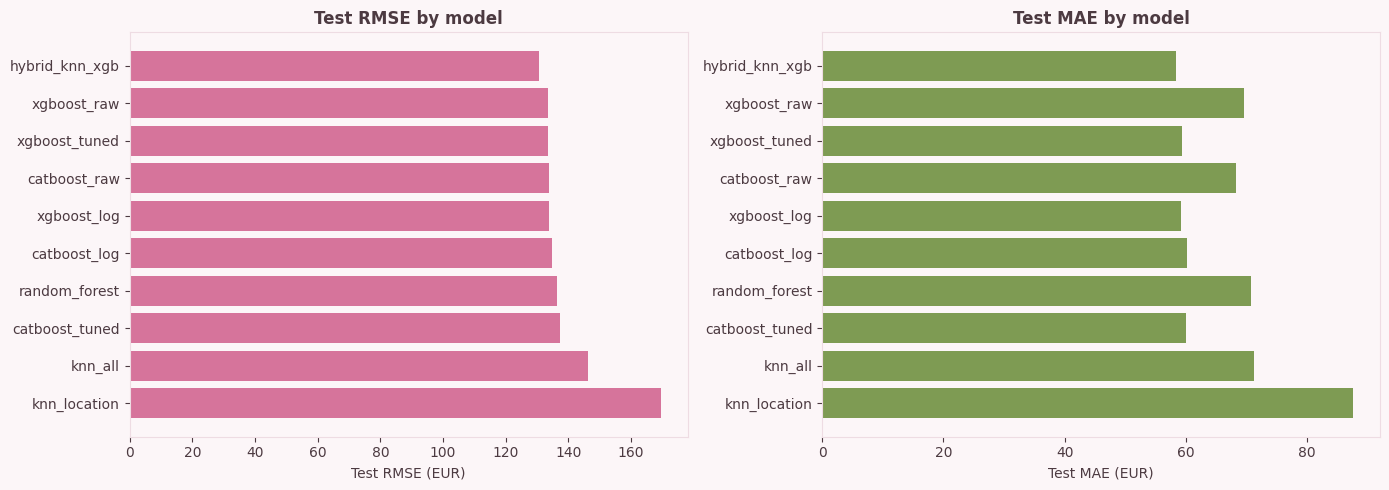

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(results_df["name"], results_df["rmse_test"], color=COLOR_PRIMARY)
axes[0].invert_yaxis()
axes[0].set_xlabel("Test RMSE (EUR)")
axes[0].set_title("Test RMSE by model")

axes[1].barh(results_df["name"], results_df["mae_test"], color=COLOR_SECONDARY)
axes[1].invert_yaxis()
axes[1].set_xlabel("Test MAE (EUR)")
axes[1].set_title("Test MAE by model")

plt.tight_layout()
plt.show()

The hybrid model (`hybrid_knn_xgb`) comes out on top on both test RMSE and test MAE here. Combining the k‑NN spatial signal with tuned XGBoost doesn't just balance the RMSE-vs-MAE trade-off seen in the other models, it actually wins outright on this run. That's a stronger result than in earlier passes at this notebook, where RMSE and MAE disagreed on a "best" model (raw-price XGBoost had the lowest RMSE, log-price/hybrid models had the lowest MAE). The added review-based features and the larger Optuna trial budget appear to have helped the hybrid model specifically. It's used as the final chosen model below both for this reason and because SHAP/robustness/export are most interesting to demonstrate on the most complete pipeline.

## 10. Robustness Check (multiple random splits)

Every result above comes from a **single** train/valid/test split (`random_state=42`). To check how much that single split affects the numbers, the whole hybrid-model pipeline (split → out-of-fold k‑NN feature → tuned XGBoost) is repeated for 5 different random seeds, and the mean and standard deviation of the test RMSE/MAE are reported.

In [35]:
def run_hybrid_for_seed(seed):
    tr_df, tmp_df = train_test_split(data_model, test_size=0.3, random_state=seed)
    va_df, te_df = train_test_split(tmp_df, test_size=0.5, random_state=seed)

    Xtr = tr_df[all_features].copy(); Xva = va_df[all_features].copy(); Xte = te_df[all_features].copy()
    for c in cat_features:
        cat_dtype = pd.CategoricalDtype(categories=data_model[c].astype("category").cat.categories)
        Xtr[c] = Xtr[c].astype(cat_dtype)
        Xva[c] = Xva[c].astype(cat_dtype)
        Xte[c] = Xte[c].astype(cat_dtype)

    scaler_s = StandardScaler().fit(tr_df[["latitude", "longitude"]])
    tr_loc = scaler_s.transform(tr_df[["latitude", "longitude"]])
    va_loc = scaler_s.transform(va_df[["latitude", "longitude"]])
    te_loc = scaler_s.transform(te_df[["latitude", "longitude"]])

    knn_s = KNeighborsRegressor(n_neighbors=best_k_loc, weights="distance")
    kf_s = KFold(n_splits=5, shuffle=True, random_state=seed)
    tr_knn_pred = cross_val_predict(knn_s, tr_loc, tr_df["log_price"], cv=kf_s)
    knn_s.fit(tr_loc, tr_df["log_price"])

    Xtr["knn_location_pred"] = tr_knn_pred
    Xva["knn_location_pred"] = knn_s.predict(va_loc)
    Xte["knn_location_pred"] = knn_s.predict(te_loc)

    model_s = XGBRegressor(objective="reg:squarederror", enable_categorical=True,
                            random_state=seed, **study.best_params)
    model_s.fit(Xtr, tr_df["log_price"])

    pred_test_s = np.expm1(model_s.predict(Xte))
    true_test_s = np.expm1(te_df["log_price"])
    return (np.sqrt(mean_squared_error(true_test_s, pred_test_s)),
            mean_absolute_error(true_test_s, pred_test_s))

seeds = [0, 1, 2, 3, 4]
seed_results = [run_hybrid_for_seed(s) for s in seeds]
seed_rmses = [r[0] for r in seed_results]
seed_maes  = [r[1] for r in seed_results]

print("Per-seed test RMSE:", [round(r, 1) for r in seed_rmses])
print("Per-seed test MAE: ", [round(r, 1) for r in seed_maes])
print(f"RMSE: {np.mean(seed_rmses):.1f} +/- {np.std(seed_rmses):.1f}")
print(f"MAE:  {np.mean(seed_maes):.1f} +/- {np.std(seed_maes):.1f}")

Per-seed test RMSE: [np.float64(157.0), np.float64(150.3), np.float64(144.6), np.float64(168.7), np.float64(141.3)]
Per-seed test MAE:  [64.1, 64.4, 61.1, 67.0, 62.5]
RMSE: 152.4 +/- 9.7
MAE:  63.8 +/- 2.0


The test RMSE varies noticeably across seeds (differences of ~20‑30 € between the best and worst split, with a standard deviation of roughly 10 €), which is on the same order as the differences between several of the models in the comparison table above. This is an important caveat: small RMSE differences between models in this notebook (e.g. `catboost_raw` vs `catboost_log`, or `xgboost_tuned` vs `hybrid_knn_xgb`) should **not** be over-interpreted as one model being reliably better than another. They are within the noise introduced by which rows happen to land in the test set.

## 11. Feature Importance (SHAP values)

As a more principled alternative to the built-in `feature_importance_`/`get_feature_importance` scores used above, exact SHAP (SHapley Additive exPlanations) values are computed for the final hybrid model. Instead of depending on the external `shap` package's `TreeExplainer` which, at the time of writing, does not reliably parse models from newer XGBoost versions, XGBoost's own native `pred_contribs=True` option is used. This computes exact SHAP values directly from the trained booster with no extra dependency and no version-compatibility risk.

In [36]:
sample = X_test_hybrid.sample(n=min(300, len(X_test_hybrid)), random_state=42)
dmat = xgb.DMatrix(sample, enable_categorical=True)

contribs = hybrid_model.get_booster().predict(dmat, pred_contribs=True)
# last column is the base value (expected output); drop it for feature-level importance
feature_contribs = contribs[:, :-1]

mean_abs_shap = np.abs(feature_contribs).mean(axis=0)
shap_importance = pd.Series(mean_abs_shap, index=sample.columns).sort_values(ascending=False)
shap_importance.head(15)

bathrooms                    0.111027
accommodates                 0.073734
bedrooms                     0.064618
knn_location_pred            0.061185
minimum_nights               0.060320
rev_sent_mean                0.053248
local_density                0.049223
rev_days_since_last          0.045327
property_type                0.033964
dist_campanile_km            0.031866
amenities_count              0.030074
rev_n_last_year              0.028819
rev_sent_std                 0.028630
review_scores_cleanliness    0.026035
rev_days_since_first         0.024634
dtype: float32

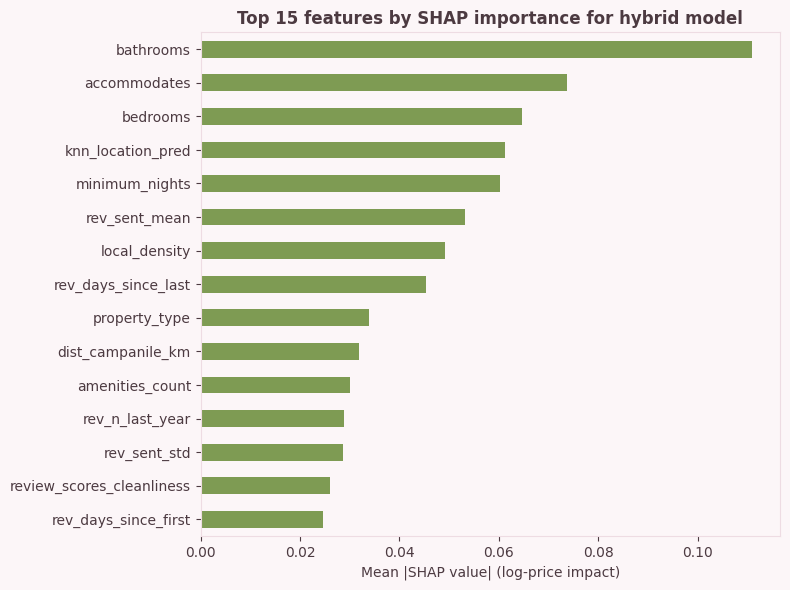

In [37]:
plt.figure(figsize=(8, 6))
shap_importance.head(15).sort_values().plot(kind="barh", color=COLOR_SECONDARY)
plt.xlabel("Mean |SHAP value| (log-price impact)")
plt.title("Top 15 features by SHAP importance for hybrid model")
plt.tight_layout()
plt.show()

`bathrooms` and `accommodates` dominate, as expected for a price model, followed closely by our new `knn_location_pred` feature, confirming that the k‑NN spatial signal is genuinely one of the more informative features for the tree model, not just noise.

## 12. Error Analysis

Beyond a single RMSE/MAE number, it helps to look at *where* the final hybrid model is wrong: a predicted-vs-actual scatter plot, residuals broken down by price range and by location cluster, a direct comparison of error on cheap vs. expensive listings, and a map of Florence with residuals plotted at each listing's location are all inspected below.

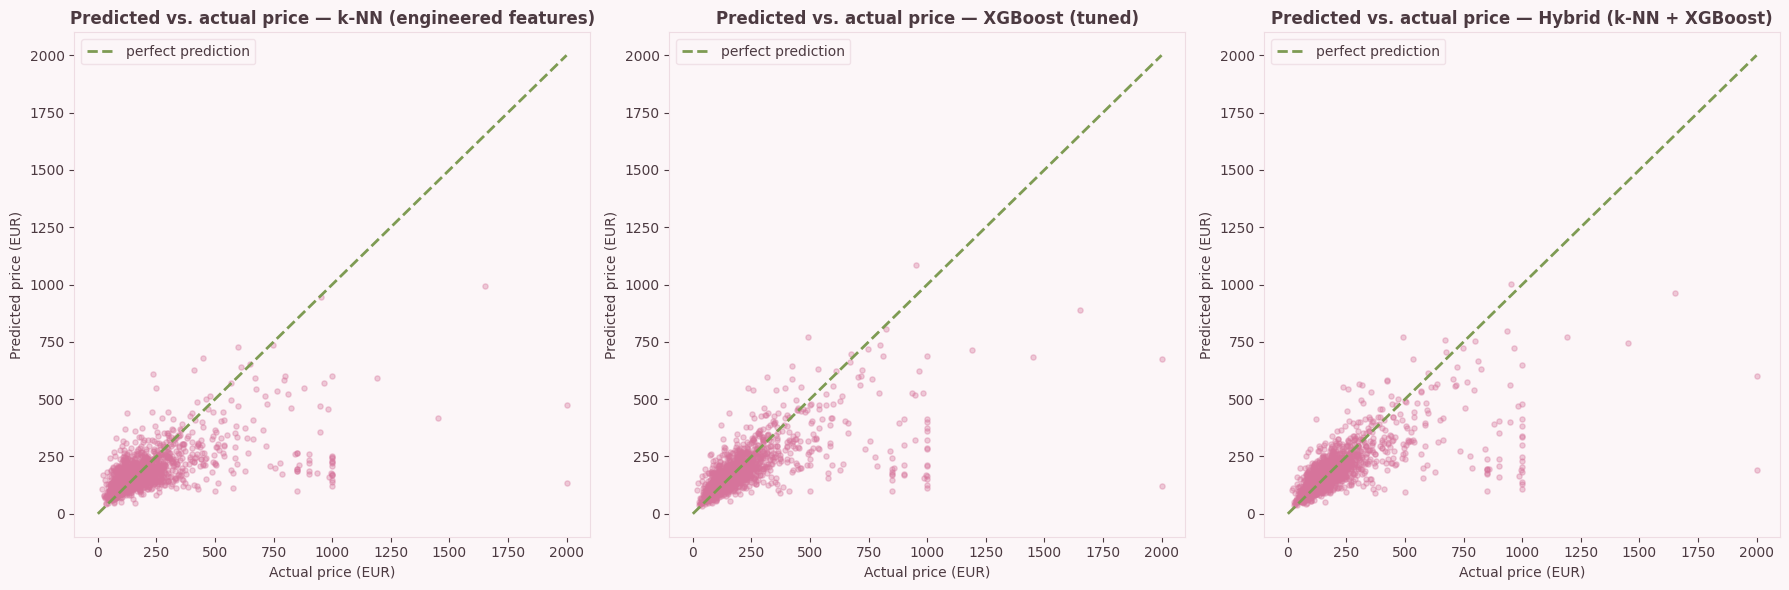

In [42]:
pred_test_hybrid  = np.expm1(hybrid_model.predict(X_test_hybrid))
pred_test_xgboost = np.expm1(xgboost_tuned.predict(X_test))
pred_test_knn     = np.expm1(knn_all_model.predict(X_test_p))
true_test         = np.expm1(test_df["log_price"])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, pred, title in zip(
    axes,
    [pred_test_knn, pred_test_xgboost, pred_test_hybrid],
    ["k-NN (engineered features)", "XGBoost (tuned)", "Hybrid (k-NN + XGBoost)"],
):
    ax.scatter(true_test, pred, alpha=0.35, s=14, color=COLOR_PRIMARY)
    lims = [0, max(true_test.max(), pred.max())]
    ax.plot(lims, lims, color=COLOR_SECONDARY, linestyle="--", linewidth=2, label="perfect prediction")
    ax.set_xlabel("Actual price (EUR)")
    ax.set_ylabel("Predicted price (EUR)")
    ax.set_title(f"Predicted vs. actual price — {title}")
    ax.legend()

plt.tight_layout()
plt.show()

In [43]:
residuals = pred_test_hybrid - true_test
price_bucket = pd.qcut(true_test, q=5)

residuals_by_price = (
    pd.DataFrame({"residual": residuals, "price_bucket": price_bucket})
    .groupby("price_bucket", observed=True)["residual"]
    .agg(["mean", "std", "count"])
)
residuals_by_price

,mean,std,count
price_bucket,,,
"(16.999, 95.0]",24.287728,29.721838,363
"(95.0, 123.0]",19.122950,33.495085,366
"(123.0, 164.0]",11.257124,38.964459,349
"(164.0, 247.0]",-5.664464,52.190046,359
"(247.0, 2000.0]",-141.686988,240.975407,359


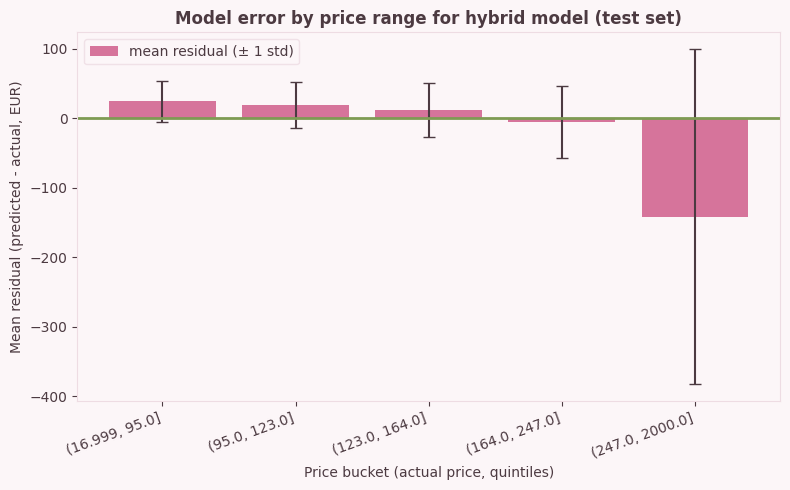

In [45]:
fig, ax = plt.subplots(figsize=(8, 5))
bucket_labels = [str(b) for b in residuals_by_price.index]
ax.bar(bucket_labels, residuals_by_price["mean"], yerr=residuals_by_price["std"],
       color=COLOR_PRIMARY, ecolor=COLOR_TEXT, capsize=4, label="mean residual (± 1 std)")
ax.axhline(0, color=COLOR_SECONDARY, linewidth=2)
ax.set_xlabel("Price bucket (actual price, quintiles)")
ax.set_ylabel("Mean residual (predicted - actual, EUR)")
ax.set_title("Model error by price range for hybrid model (test set)")
ax.legend()
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [46]:
residuals_by_cluster = (
    pd.DataFrame({"residual": residuals.values, "location_cluster": test_df["location_cluster"].values})
    .groupby("location_cluster")["residual"]
    .agg(["mean", "std", "count"])
    .sort_values("mean")
)
residuals_by_cluster

,mean,std,count
location_cluster,,,
4,-36.220366,166.769441,25
6,-25.130503,171.033521,185
2,-22.530365,136.240985,488
1,-20.397025,137.962179,54
7,-18.063476,169.815544,73
0,-14.962910,98.918089,310
3,-14.823611,115.693450,469
5,-13.513913,114.838403,192


The color-clipping (95th percentile) avoids a few extreme residuals washing out the color scale for everyone else. Marker size additionally encodes each listing's `accommodates` capacity, so it's possible to see at a glance whether the larger residuals in a given area tend to belong to bigger or smaller listings, not just where they are.

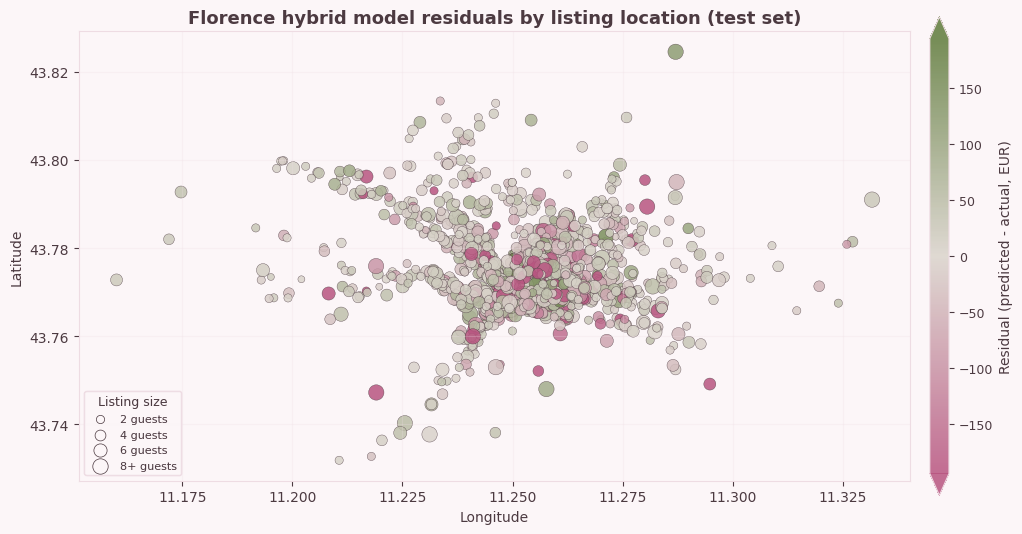

In [47]:
color_clip = np.percentile(np.abs(residuals), 95)
size_col = test_df["accommodates"].clip(upper=8)
marker_sizes = 18 + (size_col ** 1.3) * 7

fig, ax = plt.subplots(figsize=(11, 9))
sc = ax.scatter(
    test_df["longitude"], test_df["latitude"],
    c=residuals.values, cmap=RESIDUAL_CMAP, vmin=-color_clip, vmax=color_clip,
    s=marker_sizes, alpha=0.85, edgecolors=COLOR_TEXT, linewidths=0.3,
)
cbar = plt.colorbar(sc, ax=ax, extend="both", shrink=0.55, aspect=25, pad=0.02)
cbar.set_label("Residual (predicted - actual, EUR)", fontsize=10)
cbar.ax.tick_params(labelsize=9)

for n in [2, 4, 6, 8]:
    ax.scatter([], [], s=18 + (n ** 1.3) * 7, color=COLOR_SURFACE,
               edgecolors=COLOR_TEXT, linewidths=0.5, label=f"{n}{'+' if n == 8 else ''} guests")
size_legend = ax.legend(title="Listing size", loc="lower left", framealpha=0.9, fontsize=8, title_fontsize=9)
ax.add_artist(size_legend)

ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Florence hybrid model residuals by listing location (test set)", fontsize=13)
ax.set_aspect("equal"); ax.grid(True, alpha=0.25)
plt.tight_layout(); plt.show()

The scatter plot, the price-bucket breakdown, and the bucket-error chart all show a classic regression‑to‑the‑mean pattern: cheap listings are systematically **over‑predicted** (positive mean residual) and the most expensive listings are systematically **under‑predicted** (large negative mean residual), even though the model as a whole is not biased on average. The per‑cluster breakdown and the map show that the size of this effect also varies by location, some areas of Florence have much larger residual spread than others, which is worth keeping in mind when trusting a prediction for a specific listing.

### Price Distribution Sanity Check

Before looking at individual mispredicted listings, it's worth taking a quick look at how prices are distributed overall — specifically, which exact price values are most common. This becomes relevant once we look at the worst-predicted listings below.

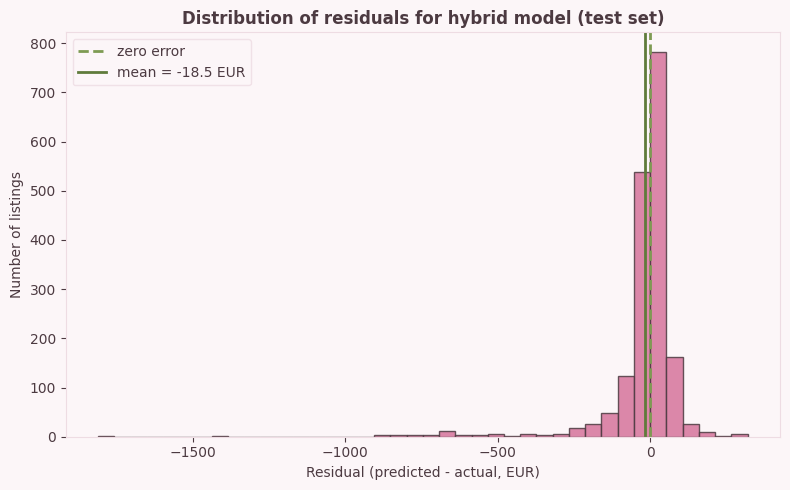

Residual mean: -18.46  std: 129.32  skew: -5.14


In [59]:
residuals = pred_test_hybrid - true_test

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(residuals, bins=40, color=COLOR_PRIMARY, edgecolor=COLOR_TEXT, alpha=0.85)
ax.axvline(0, color=COLOR_SECONDARY, linewidth=2, linestyle="--", label="zero error")
ax.axvline(residuals.mean(), color=COLOR_ACCENT, linewidth=2, label=f"mean = {residuals.mean():.1f} EUR")
ax.set_xlabel("Residual (predicted - actual, EUR)")
ax.set_ylabel("Number of listings")
ax.set_title("Distribution of residuals for hybrid model (test set)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals.mean():.2f}  std: {residuals.std():.2f}  skew: {residuals.skew():.2f}")

Looking at the most common exact prices overall, there's nothing suspicious here, 120€, 135€, 90€, 108€, 99€, 110€, 95€, 105€, 100€, and similar values are simply the price points where most listings naturally cluster, in the normal mid-range (80–180€). This alone doesn't confirm or rule out anything about round-number artifacts, since the most *frequent* prices will always sit near the middle of the distribution — rare outlier prices can't show up here regardless of whether they're real or artificial. A more targeted look at high-price listings specifically is needed.

In [60]:
comparison_df = test_df.copy()
comparison_df["predicted_price"] = pred_test_hybrid
comparison_df["actual_price"] = true_test
comparison_df["residual"] = pred_test_hybrid - true_test

display_cols = [
    "actual_price", "predicted_price", "residual",
    "room_type", "property_type", "neighbourhood_cleansed",
    "accommodates", "bedrooms", "review_scores_rating", "rev_n_reviews",
]

best_predicted = comparison_df.reindex(comparison_df["residual"].abs().sort_values().index).head(10)
worst_predicted = comparison_df.reindex(comparison_df["residual"].abs().sort_values(ascending=False).index).head(10)

print("10 best predicted listings:")
display(best_predicted[display_cols].style.background_gradient(subset=["residual"], cmap=RESIDUAL_CMAP))

print("10 worst predicted listings:")
display(worst_predicted[display_cols].style.background_gradient(subset=["residual"], cmap=RESIDUAL_CMAP))

10 best predicted listings:


,actual_price,predicted_price,residual,room_type,property_type,neighbourhood_cleansed,accommodates,bedrooms,review_scores_rating,rev_n_reviews
9755,58.000000,58.020069,0.020069,Private room,Private room in rental unit,Rifredi,2,1.000000,4.950000,20.000000
8744,133.000000,133.026550,0.026550,Entire home/apt,Entire rental unit,Centro Storico,4,1.000000,4.930000,43.000000
9021,74.000000,74.059250,0.059250,Private room,Private room in condo,Rifredi,2,1.000000,5.000000,1.000000
812,98.000000,97.925308,-0.074692,Entire home/apt,Entire rental unit,Centro Storico,3,1.000000,4.840000,332.000000
4609,133.000000,132.904022,-0.095978,Entire home/apt,Entire condo,Centro Storico,4,2.000000,4.650000,221.000000
1780,117.000000,116.891975,-0.108025,Entire home/apt,Entire rental unit,Campo di Marte,3,2.000000,4.940000,290.000000
2960,81.000000,81.130577,0.130577,Entire home/apt,Entire rental unit,Isolotto Legnaia,2,1.000000,4.890000,54.000000
2199,152.000000,151.862473,-0.137527,Entire home/apt,Entire rental unit,Centro Storico,2,1.000000,4.880000,32.000000
11913,40.000000,39.854927,-0.145073,Private room,Private room in rental unit,Isolotto Legnaia,1,1.000000,nan,0.000000
2167,60.000000,59.822933,-0.177067,Private room,Private room in condo,Rifredi,2,1.000000,4.740000,120.000000


10 worst predicted listings:


,actual_price,predicted_price,residual,room_type,property_type,neighbourhood_cleansed,accommodates,bedrooms,review_scores_rating,rev_n_reviews
9586,2000.000000,189.681976,-1810.318024,Private room,Private room in rental unit,Centro Storico,2,1.000000,4.500000,2.000000
7034,2000.000000,601.827393,-1398.172607,Entire home/apt,Entire home,Gavinana Galluzzo,10,6.000000,5.000000,8.000000
5424,1000.000000,107.579315,-892.420685,Entire home/apt,Entire condo,Campo di Marte,4,1.000000,4.910000,97.000000
4643,1000.000000,128.456894,-871.543106,Entire home/apt,Entire rental unit,Centro Storico,2,1.000000,3.000000,3.000000
9602,1000.000000,138.058548,-861.941452,Entire home/apt,Entire rental unit,Campo di Marte,7,1.000000,4.640000,22.000000
5883,986.000000,163.825836,-822.174164,Entire home/apt,Entire rental unit,Gavinana Galluzzo,5,2.000000,4.180000,11.000000
9343,1000.000000,182.630905,-817.369095,Entire home/apt,Entire rental unit,Rifredi,6,2.000000,4.700000,10.000000
5235,993.000000,189.409851,-803.590149,Private room,Private room in rental unit,Centro Storico,2,1.000000,4.800000,5.000000
457,1000.000000,205.406662,-794.593338,Hotel room,Room in serviced apartment,Centro Storico,5,2.000000,4.680000,480.000000
8587,1000.000000,231.006729,-768.993271,Entire home/apt,Entire rental unit,Centro Storico,6,2.000000,5.000000,2.000000


A few of the worst-predicted listings stand out: they tend to be small (single-bedroom, private-room, or low-capacity) listings with suspiciously round, high prices, a pattern that doesn't look like a genuine market price.

### Are These High Round Prices Real?

To check whether this is a coincidence or a real pattern, we compare how common round-number prices (multiples of 100) are among expensive listings versus the dataset as a whole.

Listings with price >= 900€: 253
Fraction on a round 100: overall = 3.9%,  high-price = 53.0%
Fraction on a round 500: overall = 1.1%,  high-price = 37.2%


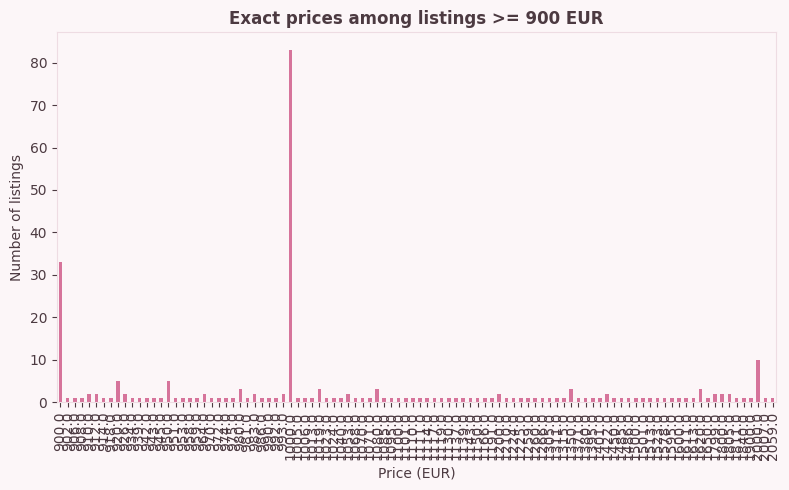

In [53]:
def round_fraction(prices, step=100):
    return (prices % step == 0).mean()

high_price = data_model[data_model["price"] >= 900]["price"]
all_price = data_model["price"]

print(f"Listings with price >= 900€: {len(high_price)}")
print(f"Fraction on a round {100}: overall = {round_fraction(all_price, 100):.1%},  high-price = {round_fraction(high_price, 100):.1%}")
print(f"Fraction on a round {500}: overall = {round_fraction(all_price, 500):.1%},  high-price = {round_fraction(high_price, 500):.1%}")

fig, ax = plt.subplots(figsize=(8, 5))
high_price.value_counts().sort_index().plot(kind="bar", ax=ax, color=COLOR_PRIMARY)
ax.set_xlabel("Price (EUR)")
ax.set_ylabel("Number of listings")
ax.set_title("Exact prices among listings >= 900 EUR")
plt.tight_layout()
plt.show()

Restricting to the 253 listings priced at 900€ or more tells a very different story. Only 3.9% of all listings have a price divisible by 100, but among these expensive listings that jumps to 53.0% — and for multiples of 500, it's 1.1% overall versus 37.2% here. The huge spike at exactly 1000€ (more than 80 listings) is the clearest signal: that's far too concentrated to be explained by chance or by normal pricing behavior.

price_bucket
(0, 100]        0.034836
(100, 200]      0.015065
(200, 300]      0.028307
(300, 400]      0.048137
(400, 500]      0.110345
(500, 600]      0.093333
(600, 700]      0.034483
(700, 800]      0.266667
(800, 900]      0.379310
(900, 1000]     0.638462
(1000, 1500]    0.070175
(1500, 2500]    0.424242
Name: price, dtype: float64


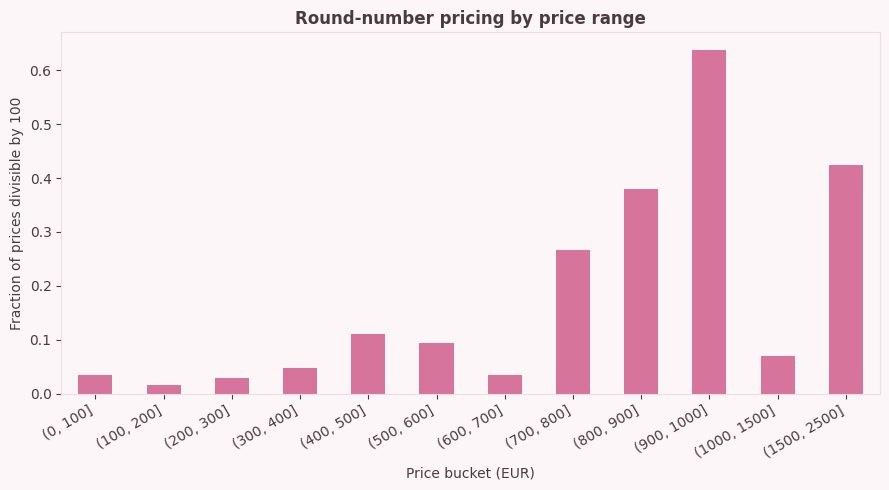

In [54]:
bins = [0, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1500, 2500]
data_model["price_bucket"] = pd.cut(data_model["price"], bins=bins)

round_by_bucket = data_model.groupby("price_bucket", observed=True)["price"].apply(
    lambda s: (s % 100 == 0).mean()
)
print(round_by_bucket)

fig, ax = plt.subplots(figsize=(9, 5))
round_by_bucket.plot(kind="bar", ax=ax, color=COLOR_PRIMARY)
ax.set_ylabel("Fraction of prices divisible by 100")
ax.set_xlabel("Price bucket (EUR)")
ax.set_title("Round-number pricing by price range")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

Splitting by price range shows this isn't a smooth trend. The round-number fraction stays low and roughly flat through the mid-range, rises somewhat through 700–900€ (27%, then 38%), spikes sharply to 64% in the (900, 1000] bucket — then drops straight back down to 7% in (1000, 1500] before jumping again to 42% in (1500, 2500]. A gradual "people round more at higher prices" effect would keep climbing rather than collapsing right after 1000€. This spike-then-drop pattern points to isolated round-number values (900/1000, then again around 1500–2000) acting as outliers, not a continuous pricing trend.

### Manual Verification

A handful of the flagged listings (small or private-room listings with round, high prices) were checked manually: some no longer exist on the platform at all, and others no longer carry those high prices. This confirms these are leftover artifacts from delisted or since-repriced listings, not genuine market prices and not a real modeling failure.

In [61]:
suspicious_price = (data_model["price"] >= 900) & (data_model["price"] % 100 == 0)

small_or_private = (
    (data_model["bedrooms"] == 1)
    | (data_model["room_type"] == "Private room")
    | (data_model["property_type"].str.contains("Private room", case=False, na=False))
    | (data_model["accommodates"] <= 3)
)

flagged = data_model[suspicious_price & small_or_private]

print(f"{len(flagged)} listings flagged")
flagged[["id", "price", "bedrooms", "accommodates", "room_type", "property_type", "neighbourhood_cleansed"]].sort_values("price", ascending=False)

72 listings flagged


,id,price,bedrooms,accommodates,room_type,property_type,neighbourhood_cleansed
1772,17308793,2000.0,1.0,2,Private room,Private room in bed and breakfast,Centro Storico
3151,33568292,2000.0,1.0,1,Private room,Private room in rental unit,Centro Storico
9586,1272361419046575308,2000.0,1.0,2,Private room,Private room in rental unit,Centro Storico
8332,1127296156855697169,1900.0,1.0,4,Entire home/apt,Entire condo,Centro Storico
7825,1070822035630367695,1800.0,1.0,4,Entire home/apt,Entire home,Centro Storico
...,...,...,...,...,...,...,...
10319,1357345167999309848,900.0,1.0,2,Entire home/apt,Entire rental unit,Centro Storico
10430,1368117148609744834,900.0,1.0,4,Entire home/apt,Entire rental unit,Centro Storico
10354,1360003820495733010,900.0,0.0,3,Entire home/apt,Entire rental unit,Centro Storico
10668,1389108685177044173,900.0,1.0,2,Entire home/apt,Entire rental unit,Centro Storico


### Model Performance Without These Artifacts

As a sensitivity check, the same hybrid pipeline is refit after removing the flagged listings entirely, to see how much of the error they were responsible for.

In [ ]:
suspicious_price = (data_model["price"] >= 900) & (data_model["price"] % 100 == 0)
print("Suspicious listings removed:", suspicious_price.sum(), "/", len(data_model))

data_model_filtered = data_model[~suspicious_price].copy()

train_df_f, temp_df_f = train_test_split(data_model_filtered, test_size=0.3, random_state=42)
valid_df_f, test_df_f = train_test_split(temp_df_f, test_size=0.5, random_state=42)

Xtr_f = train_df_f[all_features].copy(); Xva_f = valid_df_f[all_features].copy(); Xte_f = test_df_f[all_features].copy()
for c in cat_features:
    cat_dtype = pd.CategoricalDtype(categories=data_model_filtered[c].astype("category").cat.categories)
    Xtr_f[c] = Xtr_f[c].astype(cat_dtype)
    Xva_f[c] = Xva_f[c].astype(cat_dtype)
    Xte_f[c] = Xte_f[c].astype(cat_dtype)

scaler_f = StandardScaler().fit(train_df_f[["latitude", "longitude"]])
tr_loc_f = scaler_f.transform(train_df_f[["latitude", "longitude"]])
va_loc_f = scaler_f.transform(valid_df_f[["latitude", "longitude"]])
te_loc_f = scaler_f.transform(test_df_f[["latitude", "longitude"]])

knn_f = KNeighborsRegressor(n_neighbors=best_k_loc, weights="distance")
kf_f = KFold(n_splits=5, shuffle=True, random_state=42)
tr_knn_pred_f = cross_val_predict(knn_f, tr_loc_f, train_df_f["log_price"], cv=kf_f)
knn_f.fit(tr_loc_f, train_df_f["log_price"])

Xtr_f["knn_location_pred"] = tr_knn_pred_f
Xva_f["knn_location_pred"] = knn_f.predict(va_loc_f)
Xte_f["knn_location_pred"] = knn_f.predict(te_loc_f)

hybrid_model_f = XGBRegressor(objective="reg:squarederror", enable_categorical=True,
                               random_state=42, **study.best_params)
hybrid_model_f.fit(Xtr_f, train_df_f["log_price"])

pred_test_f = np.expm1(hybrid_model_f.predict(Xte_f))
true_test_f = np.expm1(test_df_f["log_price"])

rmse_test_f = np.sqrt(mean_squared_error(true_test_f, pred_test_f))
mae_test_f  = mean_absolute_error(true_test_f, pred_test_f)

rmse_orig = np.sqrt(mean_squared_error(true_test, pred_test_hybrid))
mae_orig  = mean_absolute_error(true_test, pred_test_hybrid)

print(f"Original hybrid model — Test RMSE: {rmse_orig:.2f}  MAE: {mae_orig:.2f}")
print(f"Filtered hybrid model — Test RMSE: {rmse_test_f:.2f}  MAE: {mae_test_f:.2f}")

Suspicious listings removed: 134 / 11972
Original hybrid model — Test RMSE: 130.60  MAE: 58.31
Filtered hybrid model — Test RMSE: 115.27  MAE: 51.75


Removing just 134 of 11,972 listings (1.1% of the data), those priced at 900€ or more with a suspiciously round value,  lowers test RMSE by 11.7% (130.60 → 115.27) and test MAE by 11.3% (58.31 → 51.75). A change this large from removing such a small fraction of listings confirms these aren't just a handful of hard-to-predict luxury listings: they are disproportionately responsible for the model's error, consistent with them not being genuine market prices at all. Manually checking a sample of the flagged listings backs this up further, several are no longer listed on the platform, and others no longer carry the high price. In other words, a meaningful part of this model's apparent error is a data quality issue rather than a genuine modeling limitation, and would be a good candidate to filter out upstream rather than working around it here.